In [23]:
import polars as pl

In [24]:
markets = pl.read_parquet('data/processed/markets_political.parquet')

In [26]:
# How many of your political markets have siblings?
event_counts = (markets
    .group_by('event_id')
    .agg(pl.col('condition_id').count().alias('n_siblings'))
)

markets_with_siblings = markets.join(
    event_counts,
    on='event_id',
    how='left'
)

print(markets_with_siblings['n_siblings'].describe())
print(f"Markets with 2+ siblings: {len(markets_with_siblings.filter(pl.col('n_siblings') >= 2))}")
print(f"Markets with no siblings: {len(markets_with_siblings.filter(pl.col('n_siblings') == 1))}")

shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 20689.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 11.82817 │
│ std        ┆ 9.426252 │
│ min        ┆ 1.0      │
│ 25%        ┆ 5.0      │
│ 50%        ┆ 10.0     │
│ 75%        ┆ 18.0     │
│ max        ┆ 64.0     │
└────────────┴──────────┘
Markets with 2+ siblings: 17740
Markets with no siblings: 2949


In [14]:
import mlflow

model = mlflow.xgboost.load_model("models:/polymarket-xgboost/3")

In [22]:
import numpy as np
test = pl.read_parquet('data/model/test.parquet')

for col in ['price_start', 'price_end', 'price_mean', 'price_min', 'price_max']:
    if col in test.columns:
        corr = np.corrcoef(
            test[col].to_numpy(),
            test['resolved_yes'].cast(pl.Int32).to_numpy()
        )[0,1]
        print(f"{col}: {corr:.4f}")

price_start: 0.4833
price_end: 0.8399
price_mean: 0.7869
price_min: 0.6380
price_max: 0.6241


In [3]:
import mlflow


In [4]:
client = mlflow.tracking.MlflowClient()
for rm in client.search_registered_models():
    print(f"Model name: {rm.name}")
    for version in rm.latest_versions:
        print(f"  Version: {version.version}")
        print(f"  Run ID: {version.run_id}")

In [21]:
runs = mlflow.search_runs(experiment_names=["polymarket-conformal"])
print(runs[['run_id', 'tags.mlflow.runName', 'metrics.brier_score', 'metrics.auc_roc']].head(10).to_string())

                             run_id tags.mlflow.runName  metrics.brier_score  metrics.auc_roc
0  b4f2654b5e8541b3abf98280f0b80f82         final_model             0.057260         0.972327
1  b186cc3bc0464bb485e6ba31dd2b7efb            trail_99             0.059230         0.972026
2  7db4dcdab91d45b6ae4adf86322cc6b0            trail_98             0.058772         0.971149
3  4d38c6502111418e96dcd1dc3d627130            trail_97             0.058509         0.971223
4  08cb802dc37746249e61dcc2fa1c6e8b            trail_96             0.059351         0.971479
5  f2ae82547de1402d89ab057bb7e5dfb6            trail_95             0.058475         0.969732
6  1266cd6f17664b2cbcd4f28c50afd6c1            trail_94             0.058393         0.971989
7  ff04edf7e144486a97a9d90135a9c9de            trail_93             0.059702         0.969798
8  db03f5a5f58e402ba39185f1402fede9            trail_92             0.058353         0.970225
9  558a3b90493b42e7b8873fb8c351365b            trail_91     

In [15]:
import mlflow
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    brier_score_loss, 
    roc_auc_score, 
    log_loss
)
from sklearn.calibration import calibration_curve

# Load splits
train = pl.read_parquet('data/model/train.parquet')
calibration = pl.read_parquet('data/model/calibration.parquet')
test = pl.read_parquet('data/model/test.parquet')

# Separate features and target — same logic as model.py
EXCLUDE_COLS = ['market_id', 'resolved_yes', 'end_date']
FEATURE_COLS = [c for c in train.columns if c not in EXCLUDE_COLS]

X_train = train.select(FEATURE_COLS)
y_train = train.select('resolved_yes')
X_test  = test.select(FEATURE_COLS)
y_test  = test.select('resolved_yes')

# Load model from MLflow
model = mlflow.xgboost.load_model("models:/polymarket-xgboost/1")

print("Everything loaded")

Everything loaded


In [16]:
# If this returns an array of probabilities the model is fine
test_pred = model.predict_proba(X_test.to_numpy())[:, 1]
print(test_pred[:5])
print(f"Shape: {test_pred.shape}")

[0.00289211 0.00260221 0.00238755 0.00276619 0.00312899]
Shape: (2889,)


In [17]:
# Get predictions on both train and test
y_train_proba = model.predict_proba(X_train.to_numpy())[:, 1]
y_test_proba  = model.predict_proba(X_test.to_numpy())[:, 1]

train_brier = brier_score_loss(y_train.to_numpy(), y_train_proba)
test_brier  = brier_score_loss(y_test.to_numpy(), y_test_proba)

train_auc = roc_auc_score(y_train.to_numpy(), y_train_proba)
test_auc  = roc_auc_score(y_test.to_numpy(), y_test_proba)

print(f"Train Brier: {train_brier:.4f} | Test Brier: {test_brier:.4f}")
print(f"Train AUC:   {train_auc:.4f}  | Test AUC:   {test_auc:.4f}")

Train Brier: 0.0215 | Test Brier: 0.0567
Train AUC:   0.9994  | Test AUC:   0.9717


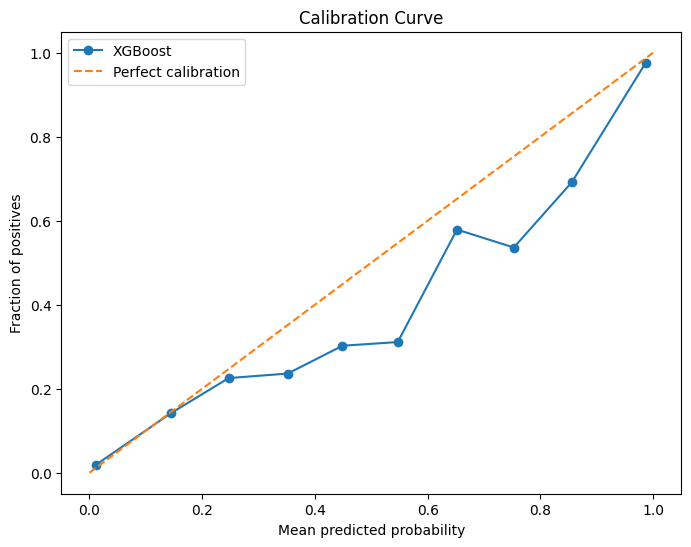

In [18]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test.to_numpy(),
    y_test_proba,
    n_bins=10
)

plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, 
         marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], 
         linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.savefig('calibration_curve.png')
plt.show()

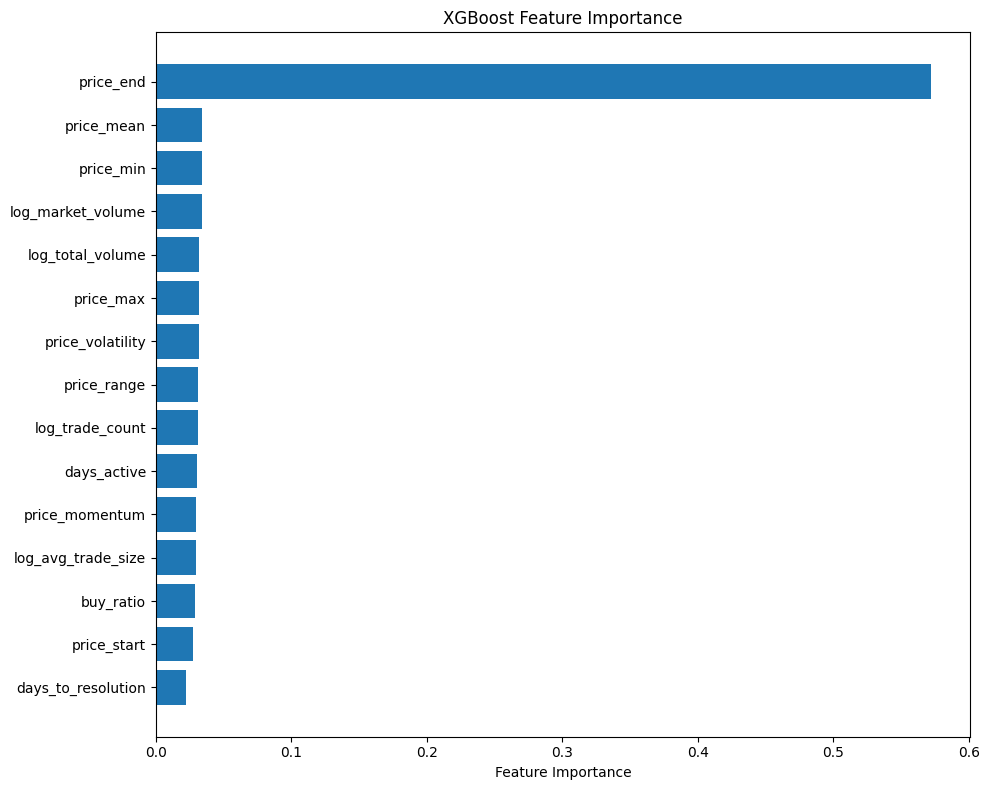

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X_train.columns
importances = model.feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(y_test_proba, bins=50, edgecolor='black')
plt.xlabel('Predicted probability of YES')
plt.ylabel('Count')
plt.title('Distribution of predicted probabilities on test set')
plt.savefig('prediction_distribution.png')
plt.show()